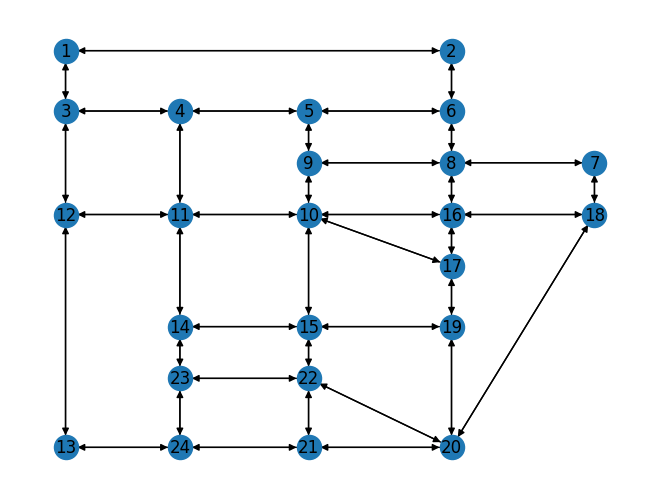

Simulation Progress:  92%|█████████▏| 660/720 [08:50<00:48,  1.25tick/s] 

✅ Simulation finished at t=3300
Total players: 2000, Finished: 2000, Unfinished: 0


In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import simpy
from tqdm import tqdm


# ===================== Lane =====================
class Lane:
    def __init__(self, lane_id: tuple, length_m: float, seg_size: int = 100, v_mps: float = 22.22):
        self.id = lane_id
        self.length = float(length_m)
        self.segment_length = int(seg_size)
        self.speed_mps = v_mps
        self.capacity_segment = self.segment_length // 5
        self._setup_segments()

    def _setup_segments(self):
        self.num_blocks = int(self.length // self.segment_length)
        self.segments = {i: 0 for i in range(self.num_blocks)}

    def travel_time(self) -> float:
        return self.length / self.speed_mps

    def add_vehicle(self, idx: int):
        if idx not in self.segments:
            raise IndexError("Segment index out of range.")
        if self.segments[idx] < self.capacity_segment:
            self.segments[idx] += 1

    def remove_vehicle(self, idx: int):
        if idx not in self.segments:
            raise IndexError("Segment index out of range.")
        if self.segments[idx] > 0:
            self.segments[idx] -= 1

    def __repr__(self):
        return (f"Lane(id={self.id}, length={self.length:.1f}, "
                f"segments={self.num_blocks}, seg_size={self.segment_length})")

    def __str__(self):
        return f"Lane {self.id} ({self.num_blocks} segments)"


# ===================== TrafficLight =====================
class TrafficLight:
    def __init__(self, light_id: int, green_sec: int = 60):
        self.id = light_id
        self.green_time = green_sec
        self.state = "RED"

    def set_green(self):
        self.state = "GREEN"

    def set_red(self):
        self.state = "RED"

    def is_green(self) -> bool:
        return self.state == "GREEN"

    def __repr__(self):
        return f"TrafficLight(id={self.id}, state={self.state})"

    def __str__(self):
        return f"TrafficLight {self.id}: {self.state}"


# ===================== Intersection =====================
class Intersection:
    def __init__(self, node_id: int, net_graph: nx.DiGraph):
        self.id = node_id
        self.incoming_nodes = list(net_graph.predecessors(node_id))
        self.lights = {src: TrafficLight(src) for src in self.incoming_nodes}
        self._index = 0

        if self.incoming_nodes:
            self.lights[self.incoming_nodes[0]].set_green()

    def control_flow(self):
        if not self.incoming_nodes:
            return
        for light in self.lights.values():
            light.set_red()
        self._index = (self._index + 1) % len(self.incoming_nodes)
        self.lights[self.incoming_nodes[self._index]].set_green()

    def __repr__(self):
        return f"Intersection(id={self.id}, incoming={self.incoming_nodes})"

    def __str__(self):
        return f"Intersection {self.id} with {len(self.incoming_nodes)} directions"


# ===================== TransportNetwork =====================
class TransportNetwork:
    def __init__(self, nodes_path: str, links_path: str, directed=True):
        self.nodes_path = nodes_path
        self.links_path = links_path
        self.directed = directed
        self.graph = nx.DiGraph() if directed else nx.Graph()

    def build(self):
        nodes = pd.read_csv(self.nodes_path).set_index("node")

        # Add nodes
        for node_id, row in nodes.iterrows():
            self.graph.add_node(int(node_id), pos=(float(row["x"]), float(row["y"])))

        # Add edges + lanes
        links = pd.read_csv(self.links_path)
        for _, row in links.iterrows():
            s, t, length = int(row["from"]), int(row["to"]), float(row["length"])
            lane_obj = Lane((s, t), length)
            self.graph.add_edge(s, t, lane=lane_obj, travel_time=lane_obj.travel_time())

        # Intersections
        for node in self.graph.nodes:
            self.graph.nodes[node]["intersection"] = Intersection(node, self.graph)

    def draw(self):
        nx.draw(
            self.graph,
            nx.get_node_attributes(self.graph, "pos"),
            node_size=300,
            with_labels=True
        )
        plt.show()


# ===================== Player =====================
class Player:
    def __init__(self, pid: str, origin: int, dest: int, graph: nx.DiGraph,
                 stats, env, arrival_t: int = 0, logged: bool = True):

        self.id = pid
        self.origin = origin
        self.destination = dest
        self.graph = graph
        self.stats = stats
        self.env = env
        self.logged = logged

        self.arrival_time = arrival_t
        self.departed = None
        self.wait_time = 0
        self.done = False

        self.path = nx.shortest_path(graph, source=origin, target=dest, weight="travel_time")

        self.current_edge = [origin, self._next_stop(origin)]

        self.intersection = graph.nodes[self.current_edge[1]]["intersection"]
        self.lane = graph.edges[tuple(self.current_edge)]["lane"]

        self.block_pos = self.lane.num_blocks - 1
        self.lane.add_vehicle(self.block_pos)

    def _next_stop(self, node: int):
        idx = self.path.index(node)
        return self.path[idx + 1] if idx + 1 < len(self.path) else None

    def _move_in_lane(self):
        next_idx = self.block_pos - 1
        if next_idx < 0:
            return

        if self.lane.segments[next_idx] < self.lane.capacity_segment:
            self.lane.remove_vehicle(self.block_pos)
            self.block_pos = next_idx
            self.lane.add_vehicle(self.block_pos)
        else:
            self.wait_time += 1

        self._log_state()

    def _pass_intersection(self):
        src = self.current_edge[0]
        light = self.intersection.lights[src]

        if light.is_green():
            self.lane.remove_vehicle(self.block_pos)
            nxt = self._next_stop(self.current_edge[1])

            if nxt is None:
                self.departed = self.env.now
                self.done = True
                self.stats.record_trip(self)
            else:
                self.current_edge = [self.current_edge[1], nxt]
                self.intersection = self.graph.nodes[self.current_edge[1]]["intersection"]
                self.lane = self.graph.edges[tuple(self.current_edge)]["lane"]
                self.block_pos = self.lane.num_blocks - 1
                self.lane.add_vehicle(self.block_pos)

        else:
            self.wait_time += 1

        self._log_state()

    def make_move(self):
        if self.done:
            return
        (self._move_in_lane() if self.block_pos > 0 else self._pass_intersection())

    def _log_state(self):
        src = self.current_edge[0]
        light_state = self.intersection.lights[src].state
        if not self.logged or self.done:
            return
        self.stats.record_detailed(
            time=self.env.now,
            player_id=self.id,
            path_from=src,
            path_to=self.current_edge[1],
            block_position=self.block_pos,
            light_state=light_state
        )


# ===================== Stats =====================
class Stats:
    def __init__(self):
        self.trips = pd.DataFrame(columns=[
            "player_id", "origin", "destination", "arrival_time",
            "departed_time", "travel_time", "wait_time"
        ])
        self.logs = pd.DataFrame(columns=[
            "time", "player_id", "path_from", "path_to",
            "block_position", "light_state"
        ])

    def record_trip(self, player):
        travel_t = player.departed - player.arrival_time if player.departed is not None else None
        new_row = {
            "player_id": player.id,
            "origin": player.origin,
            "destination": player.destination,
            "arrival_time": player.arrival_time,
            "departed_time": player.departed,
            "travel_time": travel_t,
            "wait_time": player.wait_time
        }
        self.trips = pd.concat([self.trips, pd.DataFrame([new_row])], ignore_index=True)

    def record_detailed(self, **kwargs):
        self.logs = pd.concat([self.logs, pd.DataFrame([kwargs])], ignore_index=True)


# ===================== Clock =====================
class Clock:
    def __init__(self, env, network, stats, demand_file, tick=5, light_period=60):

        self.env = env
        self.network = network
        self.stats = stats
        self.tick = tick
        self.light_cycle = light_period

        self.demand = pd.read_csv(demand_file)
        self.players = []

        for _, row in self.demand.iterrows():
            env.process(self._spawn_player(row))

        self.env.process(self._run_simulation())

    def _spawn_player(self, row):
        yield self.env.timeout(row["arrival_time"])
        player = Player(
            pid=row["player_id"],
            origin=row["source"],
            dest=row["destination"],
            graph=self.network.graph,
            stats=self.stats,
            env=self.env,
            arrival_t=row["arrival_time"]
        )
        self.players.append(player)

    def _run_simulation(self):
        while True:

            if self.env.now % self.light_cycle == 0:
                for n in self.network.graph.nodes:
                    self.network.graph.nodes[n]["intersection"].control_flow()

            for pl in self.players:
                if not pl.done and pl.arrival_time <= self.env.now:
                    pl.make_move()

            if len(self.players) == len(self.demand) and all(pl.done for pl in self.players):
                print(f"✅ Simulation finished at t={self.env.now}")
                break

            yield self.env.timeout(self.tick)


# ===================== RUN SIMULATION =====================
if __name__ == "__main__":

    # --- Build network with your paths ---
    net = TransportNetwork(
        nodes_path=r"data/network/SiouxFallsXY.csv",
        links_path=r"/Users/keivanjamali/Projects/Pure-Python/P5/08-Advanced_Traffic_TA_Class/data/network/SiouxFallsNetwork.csv"
    )
    net.build()
    net.draw()

    env = simpy.Environment()
    stats = Stats()

    clock = Clock(
        env=env,
        network=net,
        stats=stats,
        demand_file=r"/Users/keivanjamali/Projects/Pure-Python/P5/08-Advanced_Traffic_TA_Class/data/network/demand.csv",
        tick=5,
        light_period=60
    )

    MAX_TIME = 3600
    TICK = 5

    for t in tqdm(range(0, MAX_TIME, TICK), desc="Simulation Progress", unit="tick"):
        env.run(until=t + TICK)
        if not env._queue:
            break

    total = len(clock.players)
    finished = sum(p.done for p in clock.players)
    unfinished = total - finished

    print(f"Total players: {total}, Finished: {finished}, Unfinished: {unfinished}")


In [10]:
def run_simulation(
    nodes_file: str,
    links_file: str,
    demand_file: str,
    sim_duration: int = 3600,
    time_step: int = 5,
    light_cycle: int = 60
):
    """
    Initialize and execute the traffic simulation.
    Returns the Stats object containing all results.
    """
    env = simpy.Environment()
    stats = Stats()

    network = TransportNetwork(nodes_file, links_file)
    network.build()

    Clock(
        env=env,
        network=network,
        stats=stats,
        demand_file=demand_file,
        tick=time_step,
        light_period=light_cycle
    )

    env.run(until=sim_duration)
    return stats, network


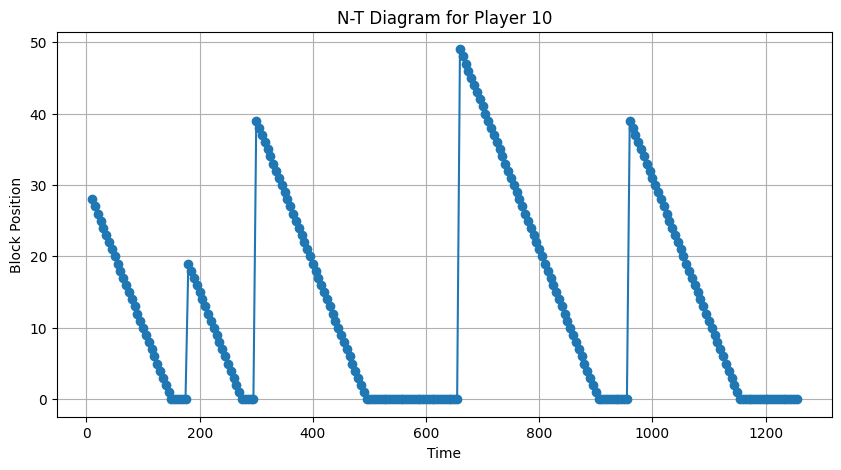

In [13]:
def plot_nt_diagram(stats, player_id: str):
    """
    Plot time-space (N-T) diagram for a specific player.
    """
    df = stats.logs[stats.logs["player_id"] == player_id]

    if df.empty:
        print(f"No data for player {player_id}")
        return

    plt.figure(figsize=(10, 5))
    plt.plot(df["time"], df["block_position"], marker="o")
    plt.xlabel("Time")
    plt.ylabel("Block Position")
    plt.title(f"N-T Diagram for Player {player_id}")
    plt.grid(True)
    plt.show()
plot_nt_diagram(stats=stats, player_id=10)

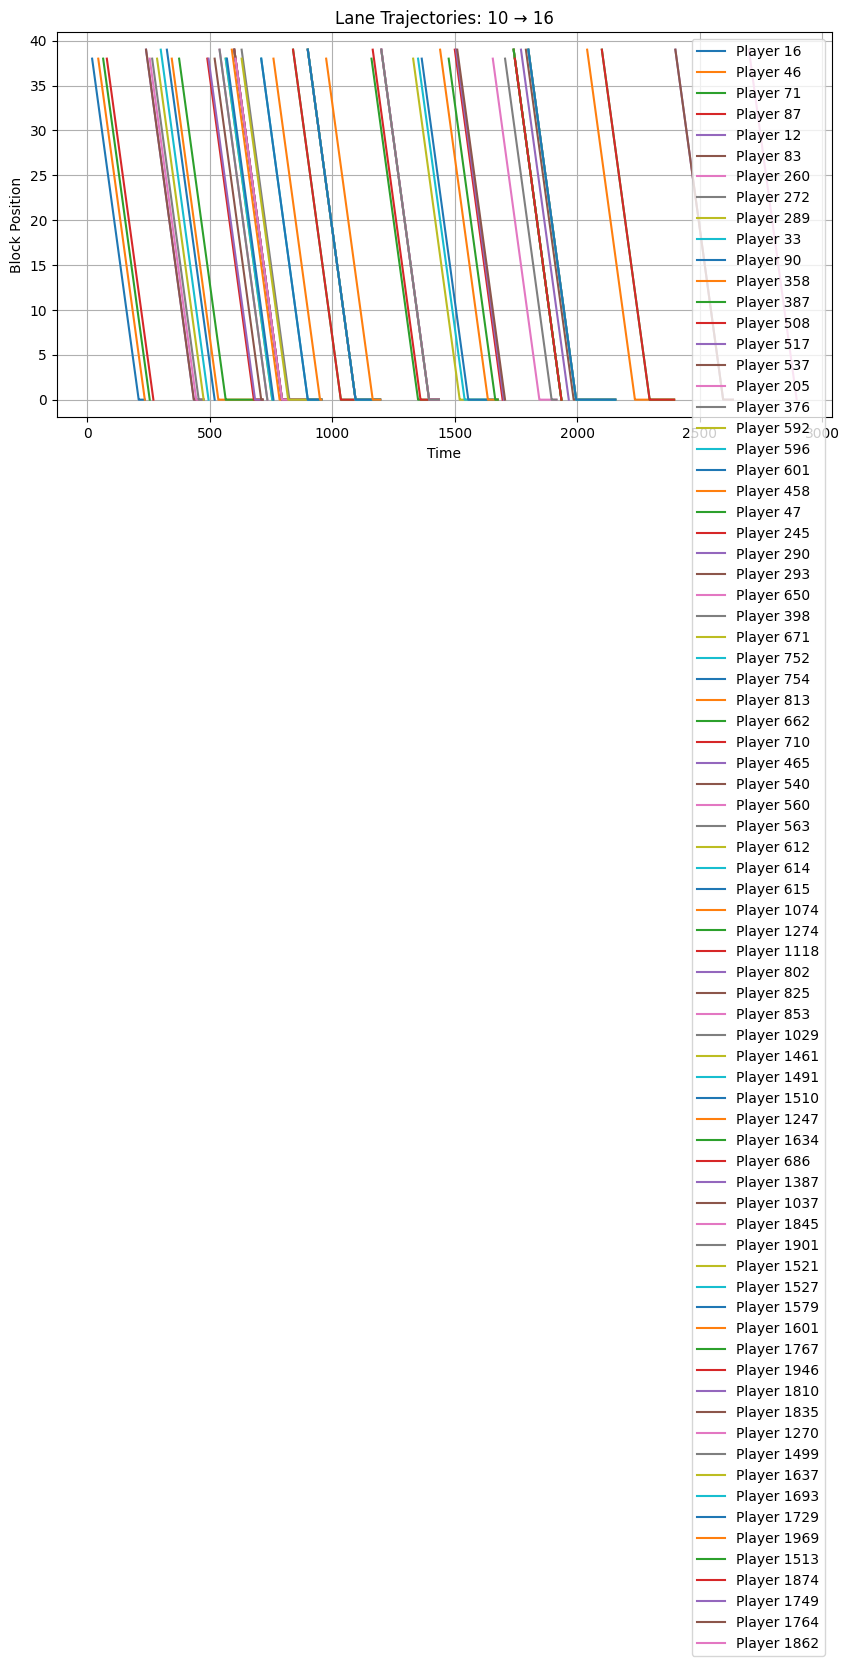

In [14]:
def plot_lane_trajectories(stats, from_node: int, to_node: int):
    """
    Plot trajectories of all players moving on a specific lane.
    """
    df = stats.logs[
        (stats.logs["path_from"] == from_node) &
        (stats.logs["path_to"] == to_node)
    ]

    if df.empty:
        print("No trajectory data for this lane.")
        return

    plt.figure(figsize=(10, 5))

    for pid in df["player_id"].unique():
        sub = df[df["player_id"] == pid]
        plt.plot(sub["time"], sub["block_position"], label=f"Player {pid}")

    plt.xlabel("Time")
    plt.ylabel("Block Position")
    plt.title(f"Lane Trajectories: {from_node} → {to_node}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_lane_trajectories(stats, 10, 16)

In [6]:
def plot_queue_diagram(stats, node_id: int):
    """
    Plot queue length evolution at an intersection.
    Queue length is approximated by vehicles at block position 0.
    """
    df = stats.logs[stats.logs["path_to"] == node_id]

    if df.empty:
        print("No queue data for this node.")
        return

    queue_df = (
        df[df["block_position"] == 0]
        .groupby("time")
        .size()
        .reset_index(name="queue_length")
    )

    plt.figure(figsize=(10, 5))
    plt.plot(queue_df["time"], queue_df["queue_length"], marker="o")
    plt.xlabel("Time")
    plt.ylabel("Queue Length")
    plt.title(f"Queue Length at Node {node_id}")
    plt.grid(True)
    plt.show()
